Raw API - Current Bitcoin Price (USD): 103307
Wrapper - Current Bitcoin Price (USD): 103307
30-day Historical BTC Prices (head):
                                price
timestamp                            
2025-04-18 03:09:09.142  84877.161759
2025-04-18 04:04:45.550  84819.481887
2025-04-18 05:04:45.687  84693.925765
2025-04-18 06:04:56.822  84680.346885
2025-04-18 07:09:09.932  84719.190447


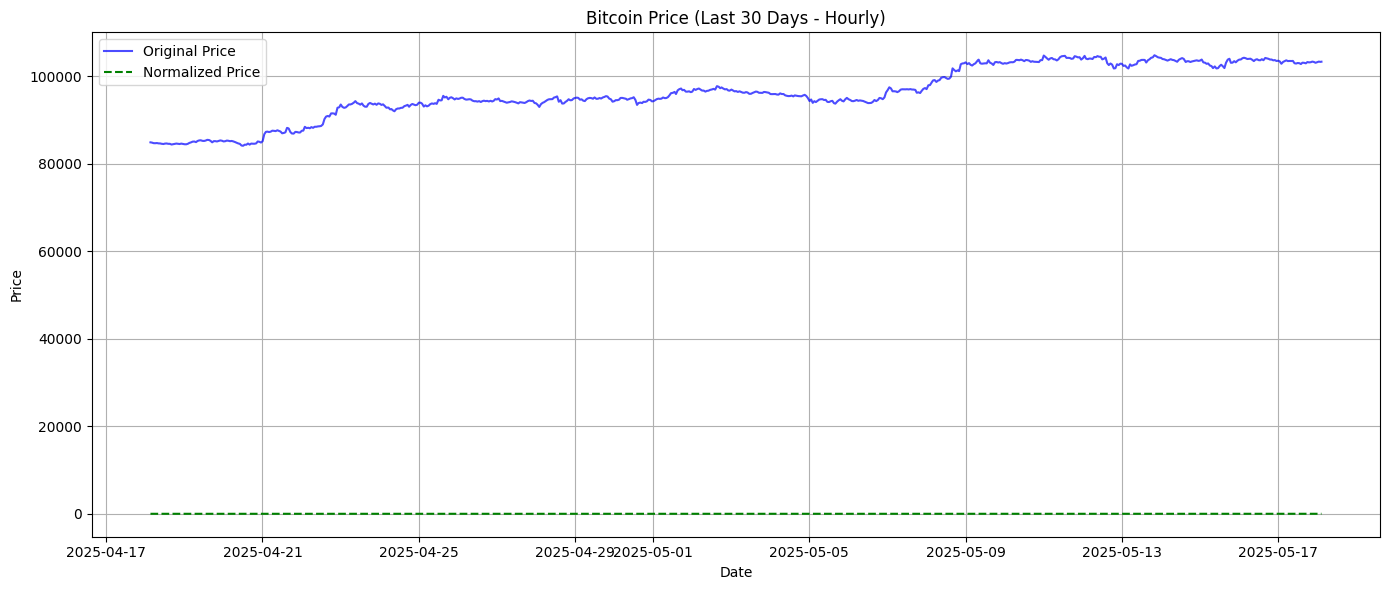

✅ Saved cleaned BTC dataset to 'bitcoin_historical.csv'


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from stablebaseline3_utils import fetch_price_now, fetch_historical_prices, normalize_prices

# Raw CoinGecko API request
url = "https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd"
response = requests.get(url)
if response.status_code == 200:
    price = response.json()['bitcoin']['usd']
    print("Raw API - Current Bitcoin Price (USD):", price)
else:
    print("API Error:", response.status_code)

# Wrapper call - fetch live price
live_price = fetch_price_now()
print("Wrapper - Current Bitcoin Price (USD):", live_price)

# Wrapper call - fetch 30 days hourly BTC prices
btc_df = fetch_historical_prices(days=30)
print("30-day Historical BTC Prices (head):")
print(btc_df.head())

# Normalize the prices
btc_df = normalize_prices(btc_df)

# Plot raw and normalized prices
plt.figure(figsize=(14, 6))
plt.plot(btc_df.index, btc_df["price"], label="Original Price", color="blue", alpha=0.7)
plt.plot(btc_df.index, btc_df["norm_price"], label="Normalized Price", color="green", linestyle="--")
plt.title("Bitcoin Price (Last 30 Days - Hourly)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Save the cleaned dataset
btc_df.to_csv("bitcoin_historical.csv")
print("✅ Saved cleaned BTC dataset to 'bitcoin_historical.csv'")
